In [1]:
import tidy3d as td
import numpy as np
import tidy3d.web as web
import matplotlib.pyplot as plt
import gdstk
import os

In [10]:
wg_height = 0.4
spot_size = 9
box_thick = 5
clad_thick = 5

# Define wavelength and frequency parameters
wl_c = 1.31
wl_bw = 0.1
wl_n = 101
wl_min = wl_c-wl_bw/2
wl_max = wl_c+wl_bw/2
freq_c = td.C_0/wl_c
freq_min = td.C_0/wl_max
freq_max = td.C_0/wl_min
freq_bw = freq_max - freq_min
wls = np.linspace(wl_min, wl_max, wl_n)
freqs = td.C_0/wls
# print(freq_bw)

tilt_angle = 10 # Tilt angle in degrees
tilt_angle_rad = np.radians(tilt_angle)

tbp_gaussian = 0.441 # Time bandwidth product for Gaussian pulse
pulse_dur = tbp_gaussian/freq_bw # Pulse duration in seconds

# Set simulation paddings
pad_x = 4*wl_c
pad_y = 4*wl_c
pad_z = 6*wl_c

# Define media
n_si3n4 = 1.96274
n_sio2 = 1.44384

Vacuum = td.Medium(
    name = 'Vacuum', 
)
si3n4 = td.Medium(
    name = 'si3n4', 
    permittivity = n_si3n4**2,
)

SiO2 = td.Medium(
    name = 'SiO2', 
    permittivity = n_sio2**2, 
)

In [12]:
# Get design cell from GDSII file
gds_path  = r'c:\users\sipho\downloads\FGC_1.gds'
lib_loaded = gdstk.read_gds(gds_path)
all_cells = {c.name: c for c in lib_loaded.cells}
print("Cell names: " + ", ".join(all_cells.keys()))
des_cell = all_cells["FGC_1"]
print(des_cell)

# Create geometry from GDS cell
des_geo = td.Geometry.from_gds(
    des_cell,
    gds_layer=733,
    gds_dtype=727,
    axis=2,
    slab_bounds=(0, wg_height),
    reference_plane = "bottom",
)

# Adjust offset of design geometry
move_by = td.Transformed.translation(3, 0, -wg_height/2)
des_geo = td.Transformed(geometry=des_geo, 
                         transform=move_by)                        
print(des_geo.bounds)
des_bounds = des_geo.bounds
des_len = des_bounds[1][0] - des_bounds[0][0]
des_wid = des_bounds[1][1] - des_bounds[0][1]

# Move design by half the x-padding to center it in the simulation domain
move_by = td.Transformed.translation(pad_x/2, 0, 0)
des_geo = td.Transformed(geometry=des_geo, 
                         transform=move_by)

print(des_geo.bounds)
des_bounds = des_geo.bounds
print("Design bounds:", des_bounds)
center_x = pad_x/2 + des_len/2

# Plot design geometry at z=0
# des_geo.plot(z=0)

# Create design structure
des = td.Structure(
    geometry=des_geo,
    medium=si3n4,
    name="Design",
)

# Create box structure
box = td.Structure(
    geometry=td.Box(
        center=(center_x, 0, -box_thick/2-wg_height/2), 
        size=(des_len, des_wid + 4, box_thick),
    ),
    medium=SiO2,
    name="Box",
)

# Create box structure
clad = td.Structure(
    geometry=td.Box(
        center=(center_x, 0, clad_thick/2-wg_height/2), 
        size=(des_len, des_wid + 4, clad_thick),
    ),
    medium=SiO2,
    name="Clad",
)


Cell names: FGC_1
Cell 'FGC_1' with 26 polygons, 0 flexpaths, 0 robustpaths, 0 references, and 0 labels
((0.0, -15.487, -0.2), (47.982, 15.487, 0.2))
((2.62, -15.487, -0.2), (50.602, 15.487, 0.2))
Design bounds: ((2.62, -15.487, -0.2), (50.602, 15.487, 0.2))


In [21]:
src_offset_x = 20.0
src_offset_y = 0.0
src_offset_z = 0.1

gaussian_source = td.GaussianBeam(
    name = 'gaussian_source', 
    center = [des_len-src_offset_x, 0, clad_thick+src_offset_z], 
    size = [1.5*spot_size, 1.5*spot_size, 0], 
    source_time = td.GaussianPulse(freq0 = freq_c,
                                   fwidth = freq_bw, ), 
    direction = '-', # Pointing down in z
    angle_theta = tilt_angle_rad, 
    waist_radius = 0.5*spot_size, 
)

xy_field = td.FieldMonitor(
    name = 'xy_field', 
    center = [center_x, 0, 0], 
    size = [des_len, des_wid+pad_y, 0], 
    freqs = freq_c, 
)

output_mode = td.ModeMonitor(
    name = 'output_mode', 
    center = [pad_x/2, 0, 0], 
    size = [0, 5, 5], 
    freqs = np.linspace(freq_min, freq_max, wl_n),
    mode_spec = td.ModeSpec(target_neff = n_si3n4, 
                            filter_pol = 'te', ), 
)

Simulation size: 58.462 41.454 16.12


<Axes: title={'center': 'cross section at y=0.00'}, xlabel='x', ylabel='z'>

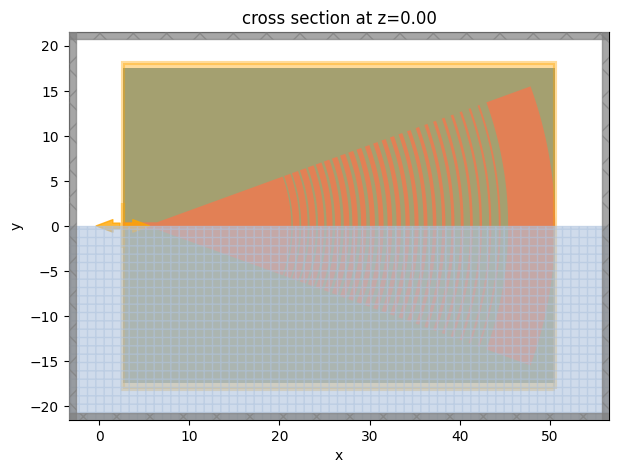

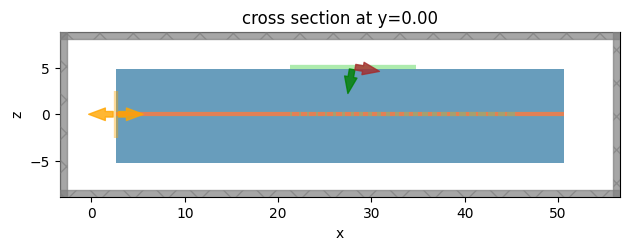

In [22]:
# Set simulation domain size
size_x = pad_x + des_len + pad_x
size_y = pad_y + des_wid + pad_y
size_z = pad_z + wg_height + pad_z
print("Simulation size:", size_x, size_y, size_z)
ng_guess = 2.0
run_time = 1.5*(des_len*ng_guess/td.C_0 + pulse_dur)

sim = td.Simulation(
    center = [center_x, 0, 0], 
    size = [size_x, size_y, size_z],
    run_time = run_time, 
    symmetry = [0, 1, 0], 
    grid_spec = td.GridSpec(grid_x = td.AutoGrid(min_steps_per_wvl = 20, ), grid_y = td.AutoGrid(min_steps_per_wvl = 20, ), grid_z = td.AutoGrid(min_steps_per_wvl = 20, ), wavelength = wl_c, ), 
    subpixel = td.SubpixelSpec(dielectric = td.PolarizedAveraging(), metal = td.Staircasing(), pec = td.PECConformal(timestep_reduction = 0.3), ), 
    medium = Vacuum,
    sources = [gaussian_source],
    monitors = [xy_field, output_mode],
    structures = [clad, box, des],
)

sim.plot(z = 0)
sim.plot(y = 0)

In [23]:
job = web.Job(simulation=sim, task_name="gc_in_coupling_3d", verbose=False)
sim_3d_in = job.run(path="data/gc3d_in_data.hdf5")

15:15:56 Eastern Daylight Time WARNING: Simulation final field decay value of   
                               0.0061 is greater than the simulation shutoff    
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

Text(0.5, 1.0, 'Maximum CE: -18.447 dB')

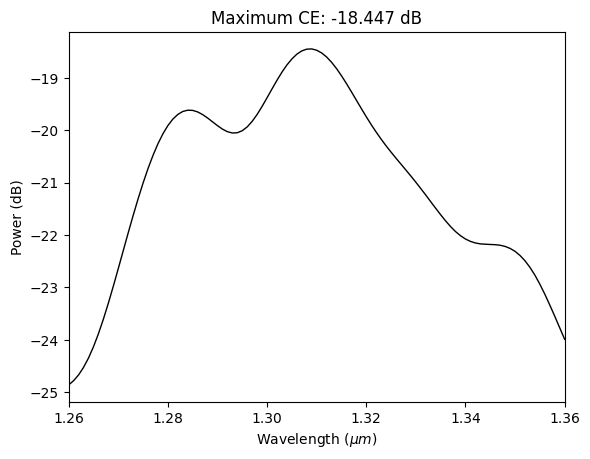

In [24]:
# Coupling Efficiency
mode_amps = sim_3d_in["output_mode"]
coeffs_f = mode_amps.amps.sel(direction="-")
power = np.abs(coeffs_f.sel(mode_index=0)) ** 2
power_db = 10 * np.log10(power)
ce_3d = np.amax(power_db)
# # Fluxes
# power_sub = abs(sim_3d_in["flux_sub"].flux)
# power_ref = abs(sim_3d_in["flux_reflected"].flux)

# fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
plt.plot(wls, power_db, color="black", linestyle="solid", linewidth=1.0)
plt.xlim([wls[0], wls[-1]])
plt.xlabel("Wavelength ($\mu m$)")
plt.ylabel("Power (dB)")
plt.title(f"Maximum CE: {ce_3d:.3f} dB")
# ax2.plot(
#     wl_range,
#     power_sub,
#     color="black",
#     linestyle="solid",
#     linewidth=1.0,
#     label="substrate",
# )
# ax2.plot(
#     wl_range,
#     power_ref,
#     color="red",
#     linestyle="solid",
#     linewidth=1.0,
#     label="reflected",
# )
# ax2.set_xlim([wl_range[0], wl_range[-1]])
# ax2.set_xlabel("Wavelength ($\mu m$)")
# ax2.set_ylabel("Power (W)")
# ax2.legend()
# plt.show()